# Load weather data from open-meteo with API request

## Steps
* get the latitude and longitude of the selected cities
* construct the request, with header information with paramaters including the latitude and longitude of the selected cities, start and end date time, hourly, the variables below 


### variables
* `temperature_2m`
* `apparent_temperature`
* `precipitation`
* `rain`
* `snowfall`
* `wind_speed_10m`
* `shortwave_radiation`

### selected cities 
	Berlin, Hamburg, München, Köln, Frankfurt


##  read weather data of the selected cities from 2019-01-01 till 2025-09-30 (time range of the electricity load file) over open-meteo archive-api

In [ ]:
import requests
import pandas as pd 

#url_open_meteo_history = 'https://open-meteo.com/en/docs/historical-weather-api'
#url_open_meteo = "https://archive-api.open-meteo.com/v1/archive?latitude=51.1657&longitude=10.4515&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m,precipitation_sum,windspeed_10m,winddirection_10m,weathercode&timezone=auto"

# contrust request URL for historical weather data for Germany (latitude: 51.1657, longitude: 10.4515) from January 1, 2019 to January 2, 2019 with hourly data for temperature_2m, apparent_temperature, precipitation, rain, snowfall, wind_speed_10m, and shortwave_radiation, weathercode and timezone set to auto
url_open_meteo_de_1d = "https://archive-api.open-meteo.com/v1/archive?latitude=51.1657&longitude=10.4515&start_date=2019-01-01&end_date=2019-01-02&hourly=temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode&timezone=auto"

response = requests.get(url_open_meteo_de_1d)
weather_data_de_1d = response.json()



,latitude,longitude,generationtime_ms,utc_offset_seconds,timezone,timezone_abbreviation,elevation,hourly_units,hourly
0,51.142353,10.502693,280.411601,7200,Europe/Berlin,GMT+2,203.0,NaN,NaN


## create dataframe with the hourly field from response including the weather data

In [11]:
df_weather_de_1d = pd.DataFrame(weather_data_de_1d['hourly'])
df_weather_de_1d['time'] = pd.to_datetime(df_weather_de_1d['time'], utc=True)
display(df_weather_de_1d.head())

,time,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode
0,2019-01-01 00:00:00+00:00,6.0,2.8,0.0,0.0,0.0,13.9,0.0,3
1,2019-01-01 01:00:00+00:00,5.8,2.3,0.0,0.0,0.0,14.8,0.0,3
2,2019-01-01 02:00:00+00:00,6.4,3.3,0.0,0.0,0.0,14.3,0.0,3
3,2019-01-01 03:00:00+00:00,6.5,2.9,0.0,0.0,0.0,17.3,0.0,3
4,2019-01-01 04:00:00+00:00,6.2,2.3,0.0,0.0,0.0,18.9,0.0,3


##  read weather data of the selected cities from 2019-01-01 till 2025-09-30 (time range of the electricity load file) over open-meteo archive-api in a loop and save the dataframes to csv for later usage


In [ ]:
import time
import requests
import pandas as pd 

# apparent_temperature is the perceived temperature, which takes into account factors such as humidity and wind speed to provide a more accurate representation of how the temperature feels to humans. It is calculated using a formula that combines the actual air temperature with the effects of humidity and wind chill. The apparent temperature can be higher than the actual temperature in hot and humid conditions, and lower than the actual temperature in cold and windy conditions.
# precipitation is the amount of water that falls from the atmosphere to the ground in the form of rain, snow, sleet, or hail. It is typically measured in millimeters (mm) or inches (in) and can be used to assess the amount of moisture in the air and the likelihood of certain weather conditions, such as flooding or drought.
# shortwave_radiation is the amount of solar radiation that reaches the Earth's surface in the form of shortwave electromagnetic waves. It is typically measured in watts per square meter (W/m²) and can be used to assess the amount of energy available for photosynthesis, as well as the potential for solar power generation.
# weathercode is a numerical code that represents the current weather conditions. It is typically used in weather forecasting and can be used to quickly identify the type of weather that is expected, such as clear skies, rain, snow, or thunderstorms.
weather_variables = ['temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'weathercode']

# get latitude and longitude of German cities: Berlin, Hamburg, München, Köln, Frankfurt
selected_cities = {  
    'Berlin': {'latitude': 52.5200, 'longitude': 13.4050},
    'Hamburg': {'latitude': 53.5511, 'longitude': 9.9937},
    'München': {'latitude': 48.1351, 'longitude': 11.5820},
    'Köln': {'latitude': 50.9375, 'longitude': 6.9603},
    'Frankfurt': {'latitude': 50.1109, 'longitude': 8.6821}
}

start_date = "2019-01-01"
end_date = "2025-09-30"
for city, coords in selected_cities.items():
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={coords['latitude']}&longitude={coords['longitude']}&start_date={start_date}&end_date={end_date}&hourly={','.join(weather_variables)}&timezone=auto"
    response = requests.get(url)
    weather_data = response.json()
    df_weather_city = pd.DataFrame(weather_data['hourly'])
    df_weather_city['time'] = pd.to_datetime(df_weather_city['time'], utc=True)
    #display(df_weather_city.head(3))
    df_weather_city.to_csv(f"../data/weather_data_{city}.csv", index=False)
    print(f"Weather data loaded and saved for: {city}")
    time.sleep(2)  # Sleep for 2 seconds to avoid hitting API rate limits

print("Weather data collection completed for all selected cities and years.")


Weather data for Berlin loaded and saved
Weather data for Hamburg loaded and saved
Weather data for München loaded and saved
Weather data for Köln loaded and saved
Weather data for Frankfurt loaded and saved
Weather data collection completed for all selected cities and years.


In [3]:
import pandas as pd 

weather_variables = ['temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'weathercode']

# calculate the weight of the cities based on their population size and use it to create a weighted average of the weather variables for Germany
city_population = {
    'Berlin': 3644826, 
    'Hamburg': 1841179, 
    'München': 1471508,     
    'Köln': 1085664, 
    'Frankfurt': 753056 
}

total_population = sum(city_population.values())
city_weights = {city: population / total_population for city, population in city_population.items()}
df_weather_germany = pd.DataFrame()
for city, weight in city_weights.items():
    df_city = pd.read_csv(f"../data/weather_data_{city}.csv")
    df_city_weighted = df_city.copy()
    for var in weather_variables:
        df_city_weighted[var] *= weight
    if df_weather_germany.empty:
        df_weather_germany = df_city_weighted
    else:
        df_weather_germany[weather_variables] += df_city_weighted[weather_variables]
df_weather_germany.to_csv("../data/weather_data_de_2019_2025.csv", index=False)
df_weather_germany.head()


,time,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode
0,2019-01-01 00:00:00+00:00,6.299668,2.974553,0.000000,0.000000,0.0,15.642783,0.0,2.914389
1,2019-01-01 01:00:00+00:00,6.287476,2.911282,0.000000,0.000000,0.0,16.353931,0.0,3.000000
2,2019-01-01 02:00:00+00:00,6.573643,3.097783,0.024685,0.024685,0.0,17.093126,0.0,8.924340
3,2019-01-01 03:00:00+00:00,6.547617,2.790544,0.012342,0.012342,0.0,18.751605,0.0,8.924340
4,2019-01-01 04:00:00+00:00,6.426409,2.295053,0.012342,0.012342,0.0,20.297058,0.0,8.924340


In [4]:
display(df_weather_germany.describe())
print(df_weather_germany.info())

,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode
count,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000
mean,11.090108,8.654784,0.091444,0.086163,0.003702,12.461484,136.406822,11.453855
std,7.623288,9.015430,0.204912,0.201910,0.022727,5.173410,199.279733,12.977756
min,-11.266880,-16.474462,0.000000,0.000000,0.000000,2.167800,0.000000,0.000000
25%,5.049001,1.232844,0.000000,0.000000,0.000000,8.721187,0.000000,1.747154
50%,10.660603,7.981214,0.012342,0.000000,0.000000,11.419630,8.846593,6.651337
75%,16.856499,15.743879,0.095215,0.083644,0.000000,15.129900,226.094303,17.204790
max,36.251328,36.253797,5.676761,5.676761,0.870161,41.066753,876.583953,72.753153


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59160 entries, 0 to 59159
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  59160 non-null  object 
 1   temperature_2m        59160 non-null  float64
 2   apparent_temperature  59160 non-null  float64
 3   precipitation         59160 non-null  float64
 4   rain                  59160 non-null  float64
 5   snowfall              59160 non-null  float64
 6   wind_speed_10m        59160 non-null  float64
 7   shortwave_radiation   59160 non-null  float64
 8   weathercode           59160 non-null  float64
dtypes: float64(8), object(1)
memory usage: 4.1+ MB
None


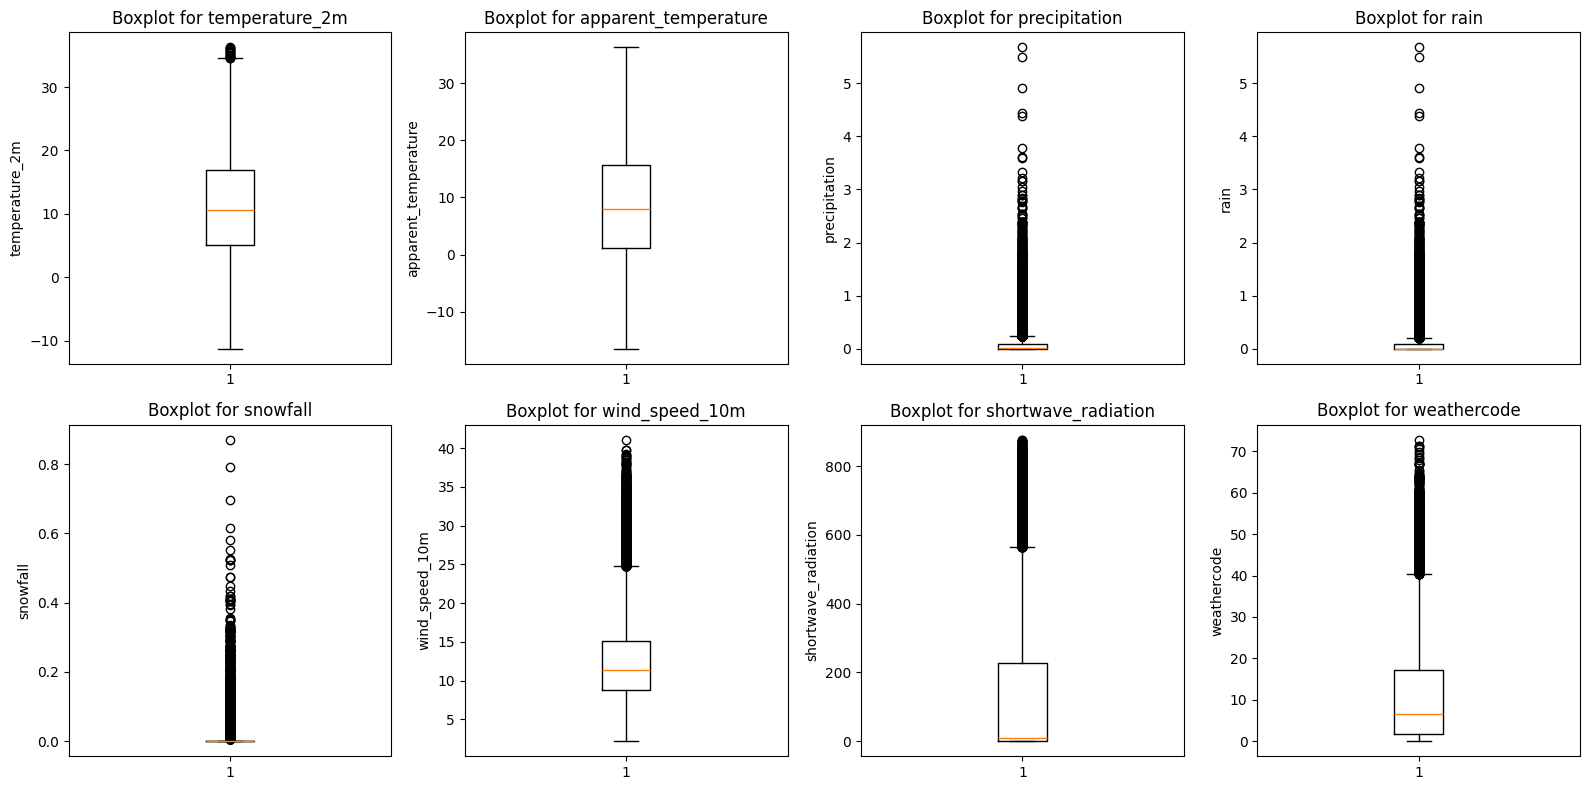

In [5]:
# check outliers in the weather data using boxplots for each weather variable
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax = ax.flatten()

for i, variable in enumerate(weather_variables): 
    ax[i].boxplot(df_weather_germany[variable])
    ax[i].set_title(f'Boxplot for {variable}')
    ax[i].set_ylabel(variable)
fig.tight_layout()
plt.show()

In [7]:
#df_weather_germany['weathercode'].value_counts()
df_weather_germany = df_weather_germany.drop('weathercode', axis=1)

Text(0.5, 1.0, 'Correlation Heatmap of Weather Variables')

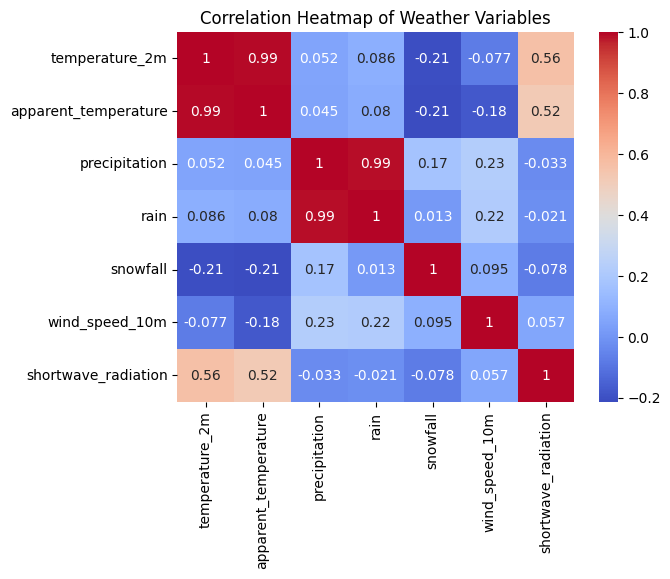

In [8]:
import seaborn as sns

weather_corr = df_weather_germany.drop('time', axis=1).corr()
sns.heatmap(weather_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Weather Variables') 


In [9]:
df_weather_germany = df_weather_germany.drop(columns=['precipitation', 'temperature_2m'], axis=1)
df_weather_germany = df_weather_germany.rename(columns={'time':"DateUTC"})
df_weather_germany.head()

,DateUTC,apparent_temperature,rain,snowfall,wind_speed_10m,shortwave_radiation
0,2019-01-01 00:00:00+00:00,2.974553,0.000000,0.0,15.642783,0.0
1,2019-01-01 01:00:00+00:00,2.911282,0.000000,0.0,16.353931,0.0
2,2019-01-01 02:00:00+00:00,3.097783,0.024685,0.0,17.093126,0.0
3,2019-01-01 03:00:00+00:00,2.790544,0.012342,0.0,18.751605,0.0
4,2019-01-01 04:00:00+00:00,2.295053,0.012342,0.0,20.297058,0.0


In [10]:
df_weather_germany.to_csv("../data/weather_data_mean_cities_2019_2025.csv", index=False)

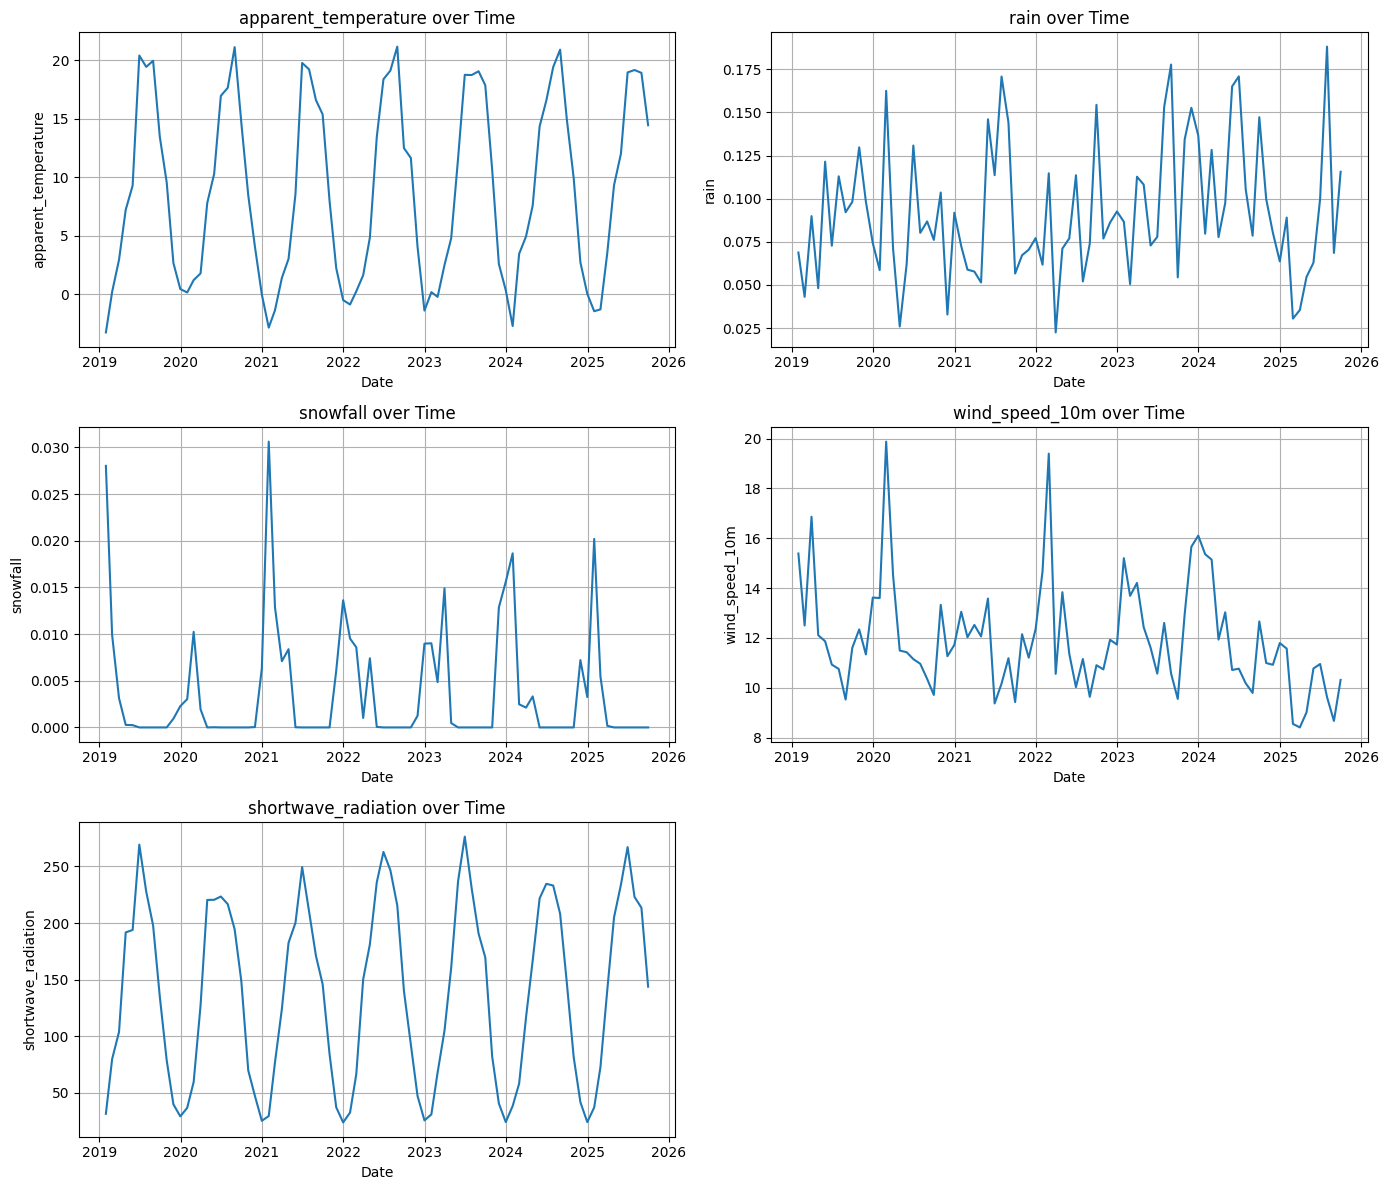

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df_weather_germany = pd.read_csv("../data/weather_data_mean_cities_2019_2025.csv", parse_dates=['DateUTC'])

# resample weather data to monthly mean values
df_weather_monthly = df_weather_germany.set_index('DateUTC').resample('ME').mean().reset_index()

# plot monthly mean values of weather variables over time
fig, ax = plt.subplots(3, 2, figsize=(14, 12))  
ax = ax.flatten()
weather_variables_monthly = ['apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation']
for i, variable in enumerate(weather_variables_monthly):  
    sns.lineplot(data=df_weather_monthly, x='DateUTC', y=variable, ax=ax[i])
    ax[i].set_title(f'{variable} over Time')
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel(variable)
    ax[i].grid()

ax[len(weather_variables_monthly)].axis('off')
plt.tight_layout()
plt.show()
